In [1]:
import pandas as pd

df = pd.read_csv("data/retail_sales.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Retail Sales Performance Dashboard for Small Business Decision-Making

## Project Introduction

This project develops a small interactive retail sales dashboard using Python and Streamlit. The purpose of the project is to help small business users understand sales trends, product category performance, regional profit differences, and key business indicators.

The intended users are small business owners, store managers, and business students who need a simple way to explore sales and profit data. Instead of only displaying raw transaction records, this project uses Python to clean, transform, summarise, and visualise the dataset.

The analytical problem is:

**How can small business users identify important sales patterns and profit differences from retail transaction data?**

The dataset used in this project is a sample retail sales dataset. It includes information such as order dates, customer segments, regions, product categories, sales, quantity, discount, and profit. These variables are suitable for analysing retail performance and building a basic business dashboard.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [3]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning and Preparation

The dataset was first inspected using `df.info()`, `df.isnull().sum()`, and `df.duplicated().sum()` to understand its structure, missing values, and duplicate records.

The dataset contains 9,994 rows and 21 columns. Most variables have no missing values. The only missing values are found in `Postal Code`, which is not a core variable in this analysis. Therefore, these missing values do not affect the main sales and profit analysis.

No duplicated rows were found in the dataset. The `Order Date` and `Ship Date` columns were converted into datetime format so that monthly and yearly sales trends could be analysed. Additional variables, including `Month`, `Year`, and `Profit Margin`, were also created to support the analysis and dashboard design.

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [6]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Year"] = df["Order Date"].dt.year
df["Profit Margin"] = df["Profit"] / df["Sales"]

df[["Order Date", "Month", "Year", "Sales", "Profit", "Profit Margin"]].head()

,Order Date,Month,Year,Sales,Profit,Profit Margin
0,2017-11-08,2017-11,2017,261.9600,41.9136,0.1600
1,2017-11-08,2017-11,2017,731.9400,219.5820,0.3000
2,2017-06-12,2017-06,2017,14.6200,6.8714,0.4700
3,2016-10-11,2016-10,2016,957.5775,-383.0310,-0.4000
4,2016-10-11,2016-10,2016,22.3680,2.5164,0.1125


## Methods and Analysis Approach

This project uses descriptive data analysis to summarise and interpret retail sales performance. The main Python library used is `pandas`, which supports data loading, cleaning, transformation, grouping, and aggregation.

The analysis focuses on five main areas:

1. Overall business performance, including total sales, total profit, total quantity, average profit margin, and total orders.
2. Monthly sales trends, which show how sales change over time.
3. Product category performance, which compares sales and profit across different product categories.
4. Regional performance, which compares sales and profit across different regions.
5. Top sub-category performance, which identifies the sub-categories that contribute most to total sales.

These outputs are later used to design the Streamlit dashboard, where users can explore the dataset interactively through filters, summary metrics, charts, and tables.

In [7]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
average_profit_margin = df["Profit Margin"].mean()
total_orders = df["Order ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)
print("Average Profit Margin:", round(average_profit_margin, 4))
print("Total Orders:", total_orders)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873
Average Profit Margin: 0.1203
Total Orders: 5009


In [8]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

monthly_sales.head()

,Month,Sales
0,2015-01,14236.895
1,2015-02,4519.892
2,2015-03,55691.009
3,2015-04,28295.345
4,2015-05,23648.287


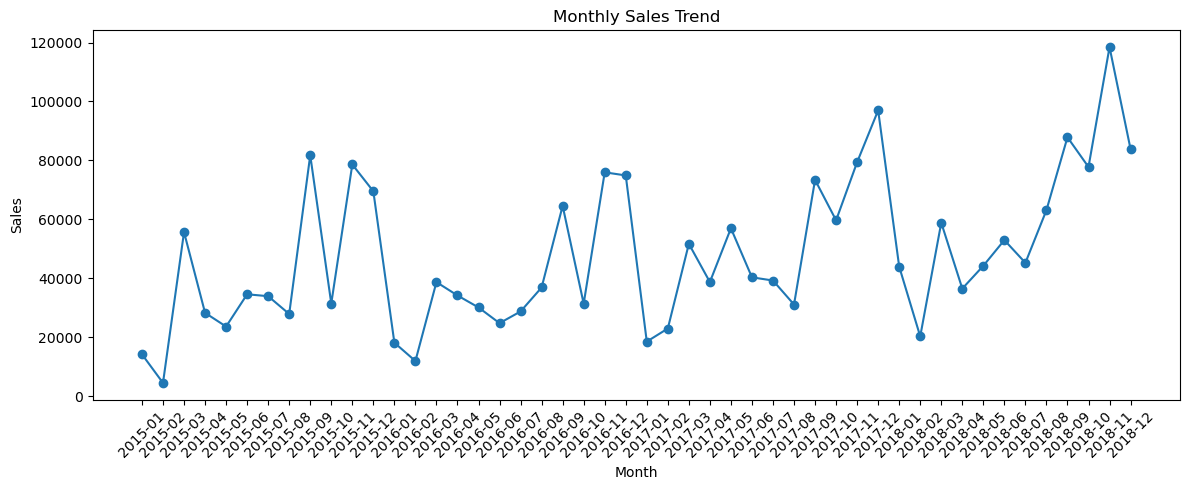

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
category_summary = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()
category_summary = category_summary.sort_values("Sales", ascending=False)

category_summary

,Category,Sales,Profit
2,Technology,836154.0330,145454.9481
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008


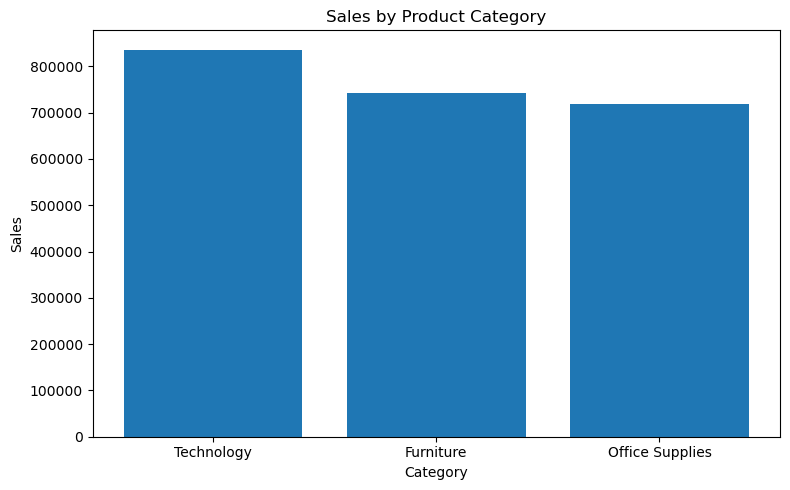

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(category_summary["Category"], category_summary["Sales"])
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [12]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
region_summary = region_summary.sort_values("Profit", ascending=False)

region_summary

,Region,Sales,Profit
3,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
0,Central,501239.8908,39706.3625


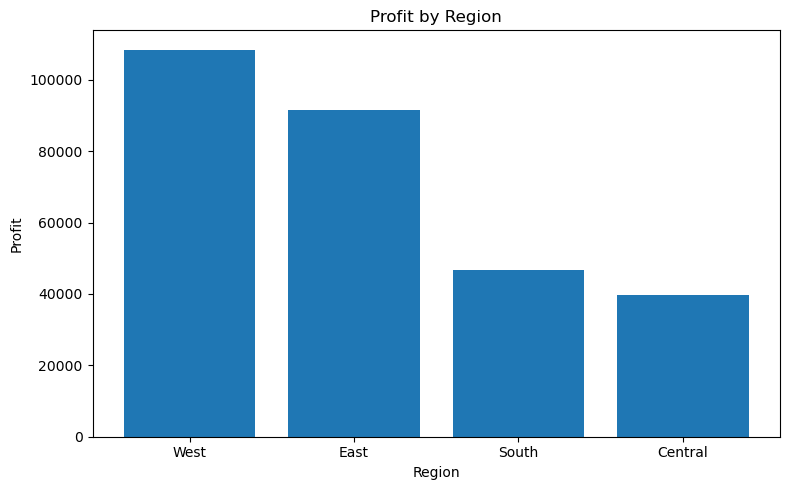

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(region_summary["Region"], region_summary["Profit"])
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [14]:
top_subcategories = df.groupby("Sub-Category")[["Sales", "Profit"]].sum().reset_index()
top_subcategories = top_subcategories.sort_values("Sales", ascending=False).head(10)

top_subcategories

,Sub-Category,Sales,Profit
13,Phones,330007.0540,44515.7306
5,Chairs,328449.1030,26590.1663
14,Storage,223843.6080,21278.8264
16,Tables,206965.5320,-17725.4811
3,Binders,203412.7330,30221.7633
11,Machines,189238.6310,3384.7569
0,Accessories,167380.3180,41936.6357
6,Copiers,149528.0300,55617.8249
4,Bookcases,114879.9963,-3472.5560
1,Appliances,107532.1610,18138.0054


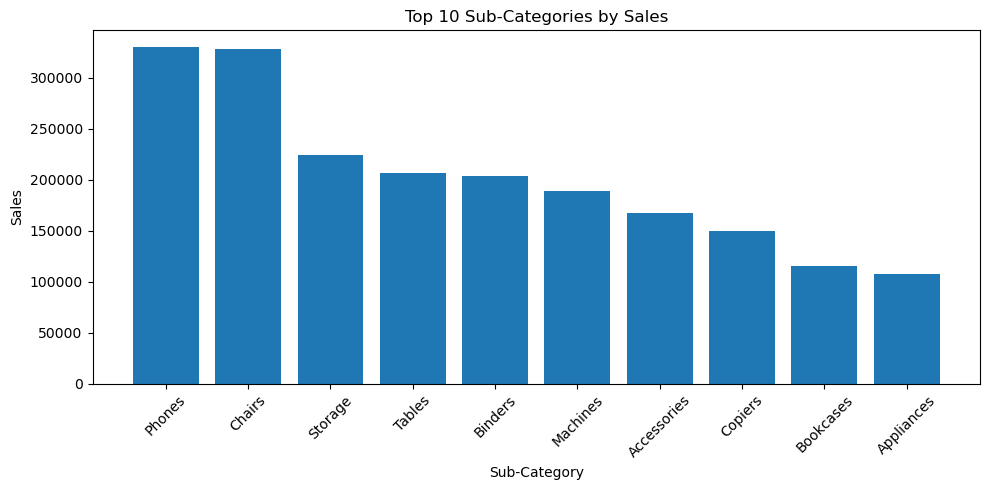

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(top_subcategories["Sub-Category"], top_subcategories["Sales"])
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_month = monthly_sales.sort_values("Sales", ascending=False).iloc[0]
best_category_sales = category_summary.sort_values("Sales", ascending=False).iloc[0]
best_category_profit = category_summary.sort_values("Profit", ascending=False).iloc[0]
best_region_profit = region_summary.sort_values("Profit", ascending=False).iloc[0]
top_subcategory_sales = top_subcategories.sort_values("Sales", ascending=False).iloc[0]

print("Key Findings Summary")
print("--------------------")
print(f"Highest sales month: {best_month['Month']} with sales of {best_month['Sales']:.2f}")
print(f"Top category by sales: {best_category_sales['Category']} with sales of {best_category_sales['Sales']:.2f}")
print(f"Top category by profit: {best_category_profit['Category']} with profit of {best_category_profit['Profit']:.2f}")
print(f"Top region by profit: {best_region_profit['Region']} with profit of {best_region_profit['Profit']:.2f}")
print(f"Top sub-category by sales: {top_subcategory_sales['Sub-Category']} with sales of {top_subcategory_sales['Sales']:.2f}")

## Key Findings

The analysis produced several useful insights for small business decision-making.

First, the highest monthly sales occurred in **November 2018**, with total sales of **118,447.82**. This suggests that sales performance may be stronger near the end of the year, possibly due to seasonal demand or holiday-related purchasing.

Second, **Technology** was the strongest product category in both total sales and total profit. It generated **836,154.03** in sales and **145,454.95** in profit. This indicates that Technology is not only a high-revenue category but also an important source of profitability.

Third, the **West** region generated the highest profit, with total profit of **108,418.45**. This suggests that regional performance differs and that the West region may be especially valuable for the business.

Finally, **Phones** was the top sub-category by sales, with total sales of **330,007.05**. This shows that specific sub-categories can make a major contribution to overall sales performance.

## Limitations

This project has several limitations. First, the dataset appears to be a sample retail dataset rather than real-time company data, so the results should be used for educational analysis rather than direct business decisions.

Second, the analysis is mainly descriptive. It focuses on sales, profit, product categories, regions, and monthly trends, but it does not include advanced forecasting or causal analysis.

Third, some external factors are not included in the dataset, such as marketing campaigns, competitor behaviour, customer income, economic conditions, or holiday effects. These factors may also influence retail sales performance.

Finally, although the dashboard can help users explore key patterns, the results depend on the quality and completeness of the dataset. Future improvements could include adding more recent data, customer-level analysis, forecasting, and more detailed profit margin analysis.